In [6]:
!pip install qiskit qiskit-aer

In [7]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np
print('Qiskit Aer noise tools ready ✓')

Qiskit Aer noise tools ready ✓


In [13]:
# Perfect Bell state: should give 50% |00⟩ and 50% |11⟩
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0,1],[0,1])

sim_ideal = AerSimulator()
counts_ideal = sim_ideal.run(qc, shots=4096).result().get_counts()
print(f'Ideal counts: {counts_ideal}')

Ideal counts: {'11': 2047, '00': 2049}


In [14]:
# Build a noise model with depolarizing errors
noise_model = NoiseModel()

# 1% gate error on single-qubit gates
error_1q = depolarizing_error(0.01, 1)
noise_model.add_all_qubit_quantum_error(error_1q, ['h', 'x', 'rz', 's', 't'])

# 3% gate error on two-qubit gates
error_2q = depolarizing_error(0.03, 2)
noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

print(noise_model)



NoiseModel:
  Basis gates: ['cx', 'h', 'id', 'rz', 's', 'sx', 't', 'x']
  Instructions with noise: ['t', 's', 'h', 'rz', 'cx', 'x']
  All-qubits errors: ['h', 'x', 'rz', 's', 't', 'cx']


In [16]:
sim_noisy = AerSimulator(noise_model=noise_model)
counts_noisy = sim_noisy.run(qc, shots=4096).result().get_counts()
print(f'Noisy counts: {counts_noisy}')



Noisy counts: {'01': 29, '11': 2052, '10': 18, '00': 1997}


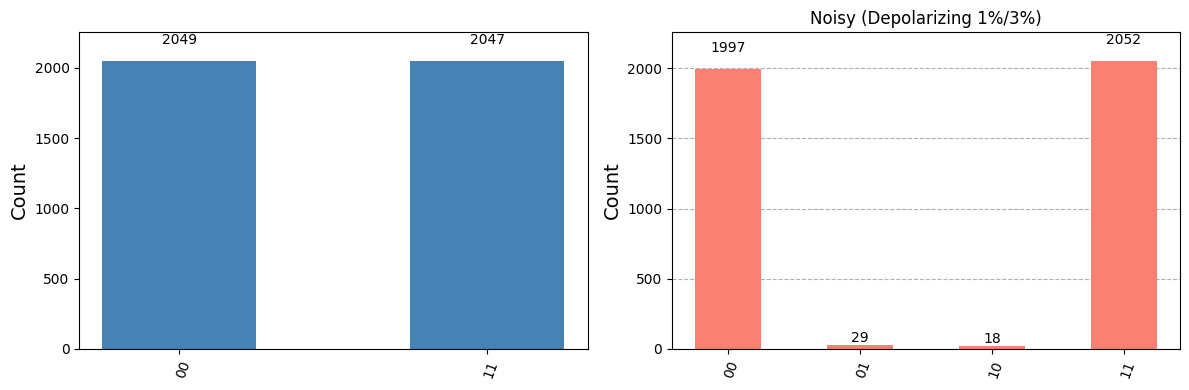

In [17]:
# Compare ideal vs noisy
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_histogram(counts_ideal, ax=axes[0], title='Ideal (No Noise)', color='steelblue')
plot_histogram(counts_noisy,  ax=axes[1], title='Noisy (Depolarizing 1%/3%)', color='salmon')
plt.tight_layout()
plt.show()

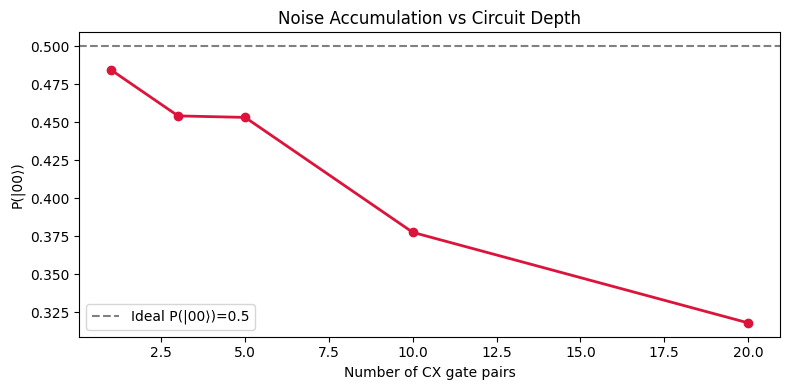

In [18]:
# Observe how noise degrades fidelity as circuit depth increases
n_cx_gates = [1, 3, 5, 10, 20]
counts_00 = []

for n_cx in n_cx_gates:
    qc_deep = QuantumCircuit(2, 2)
    qc_deep.h(0)
    for _ in range(n_cx):
        qc_deep.cx(0, 1)
        qc_deep.cx(1, 0)  # cancel out but adds noise
    qc_deep.measure([0,1],[0,1])
    counts = sim_noisy.run(qc_deep, shots=2048).result().get_counts()
    p00 = counts.get('00', 0) / 2048
    counts_00.append(p00)

plt.figure(figsize=(8, 4))
plt.plot(n_cx_gates, counts_00, 'o-', color='crimson', linewidth=2)
plt.axhline(0.5, linestyle='--', color='gray', label='Ideal P(|00⟩)=0.5')
plt.xlabel('Number of CX gate pairs')
plt.ylabel('P(|00⟩)')
plt.title('Noise Accumulation vs Circuit Depth')
plt.legend()
plt.tight_layout()
plt.show()


In [19]:
# Add readout error
readout_error = ReadoutError([[0.95, 0.05], [0.08, 0.92]])  # 5% and 8% flip rates
noise_model_ro = NoiseModel()
noise_model_ro.add_all_qubit_readout_error(readout_error)

sim_ro = AerSimulator(noise_model=noise_model_ro)

# Apply to a simple |0⟩ circuit (should measure all 0s)
qc_simple = QuantumCircuit(1, 1)
qc_simple.measure(0, 0)
counts_ro = sim_ro.run(qc_simple, shots=4096).result().get_counts()
print(f'|0⟩ with readout error: {counts_ro}')
print(f'Expected "1" fraction (noise): {counts_ro.get("1",0)/4096:.3f} (ideal: 0.000)')

|0⟩ with readout error: {'0': 3892, '1': 204}
Expected "1" fraction (noise): 0.050 (ideal: 0.000)


In [20]:

noise_model_5pct = NoiseModel()
error_5pct = depolarizing_error(0.05, 1)
noise_model_5pct.add_all_qubit_quantum_error(error_5pct, ['h', 'x'])
sim_5pct = AerSimulator(noise_model=noise_model_5pct)
counts_5pct = sim_5pct.run(qc, shots=4096).result().get_counts()
print(counts_5pct)

{'00': 2023, '11': 2073}


The Bell State fidelity decreases when noise is added because the quantum gates are no longer perfect. The noise simulation produces some incorrect measurement outcomes (01 and 10) that do not appear in the ideal bell state, showing that the entangled state has been degraded.

In [21]:
device_specs = {
    'device_name': 'IonQ Aria',
    'n_qubits': 25 ,
    'T1_us': '10-100s' ,
    'T2_us':'1s' ,
    'cx_fidelity': 0.994,
    'quantum_volume': 'N/A (IonQ uses Algorithmic Qubits #AQ = 25)'
}

print(device_specs)

{'device_name': 'IonQ Aria', 'n_qubits': 25, 'T1_us': '10-100s', 'T2_us': '1s', 'cx_fidelity': 0.994, 'quantum_volume': 'N/A (IonQ uses Algorithmic Qubits #AQ = 25)'}


Key Takeaways
Noise is the central challenge of NISQ computing — it limits circuit depth
Depolarizing noise drives states toward uniform mixtures
Readout error misclassifies measurement outcomes
Near-term QML must use shallow, noise-resilient circuits
Error mitigation (not correction) is the practical NISQ approach

📝 TODO Checklist
Complete Exercise 1: 5% depolarizing noise Bell fidelity
Complete Exercise 2: Real device specs research

Explore amplitude damping noise model

code below.

Plot T1 decay curve for a |1⟩ state with amplitude damping

code below.

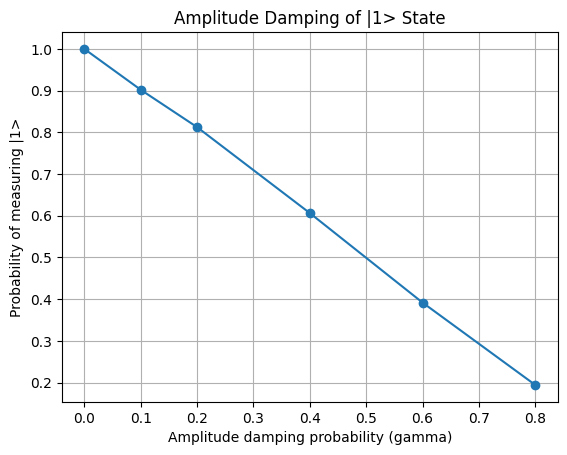

In [25]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, amplitude_damping_error
import matplotlib.pyplot as plt

gammas = [0, 0.1, 0.2, 0.4, 0.6, 0.8]
prob_1 = []

for gamma in gammas:
    noise_model = NoiseModel()

    damping = amplitude_damping_error(gamma)

    noise_model.add_all_qubit_quantum_error(
        damping,
        ['x']
    )

    simulator = AerSimulator(noise_model=noise_model)

    qc = QuantumCircuit(1, 1)
    qc.x(0)
    qc.measure(0, 0)

    counts = simulator.run(qc, shots=4096).result().get_counts()
    p1 = counts.get('1', 0) / 4096

    prob_1.append(p1)

plt.plot(gammas, prob_1, 'o-')
plt.xlabel("Amplitude damping probability (gamma)")
plt.ylabel("Probability of measuring |1>")
plt.title("Amplitude Damping of |1> State")
plt.grid(True)
plt.show()

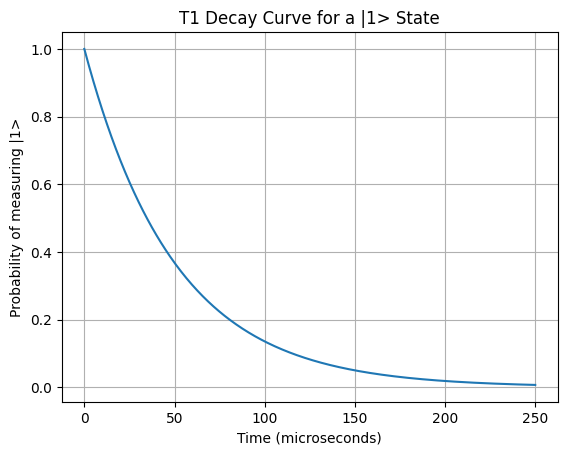

In [24]:
import numpy as np
import matplotlib.pyplot as plt

T1 = 50  # microseconds
t = np.linspace(0, 5*T1, 500)

prob_1_t = np.exp(-t / T1)

plt.plot(t, prob_1_t)
plt.xlabel("Time (microseconds)")
plt.ylabel("Probability of measuring |1>")
plt.title("T1 Decay Curve for a |1> State")
plt.grid(True)
plt.show()

The first plot explores amplitude damping by increasing gamma. As gamma increases, the probability of measuring |1> decreases because the qubit relaxes toward |0>. The second plot shows the T1 decay curve over time, where the excited-state probability follows P(|1>) = exp(-t/T1). At one T1 time, only about 36.8% of the |1> population remains.